In [1]:
import pickle as pk
import numpy as np
import matplotlib.pyplot as pl
pl.rc('text', usetex=True)
%matplotlib inline
import os
import sys, os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
from jax.lib import xla_bridge
platform = xla_bridge.get_backend().platform
import jax
import jax.numpy as jnp
from jax import vmap, grad, pmap
print(jax.local_device_count(), jax.device_count())
jax.config.update('jax_platform_name', platform)
jax.config.update("jax_enable_x64", True)

import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 
sys.path.append((curr_path))
sys.path.append((abs_path_data))
sys.path.append((abs_path_results))
sys.path.append(abs_path_src)

from jax import config
import scipy.interpolate as interp
import pickle as pk
import numpy as np
import colossus 
import configobj

from godmax.base_class import base_class
from godmax.get_radial_profiles import Profiles
from godmax.get_Pkzs import get_Pkz
from godmax.get_Cls import get_Cl
from godmax.get_Xis import get_xi
from godmax.get_covs import get_cov
import matplotlib.pyplot as pl
from jax_cosmo import Cosmology
from jax_cosmo.background import angular_diameter_distance, radial_comoving_distance
from astropy import constants as const
import jax_cosmo.background as bkgrd

%matplotlib inline



%load_ext autoreload
%autoreload 2




/tmp/ipykernel_4039425/842995827.py:10: DeprecationWarning: jax.lib.xla_bridge.get_backend is deprecated; use jax.extend.backend.get_backend.
  platform = xla_bridge.get_backend().platform


1 1


In [2]:
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
# sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(default_data)
new_data = read_yaml(abs_path_params + '/Pge/params.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)

# analysis_dict['beam_fwhm_arcmin'] = 1.4
df_nz_comoving = np.loadtxt(abs_path_data + '/pge/comoving_nz_bgs_lrg_DESIY3_key_zall.txt')
zarray_comoving = df_nz_comoving[:,0]
nz_comoving_orig = df_nz_comoving[:,1]
indsel = np.where(zarray_comoving < 0.4)[0]
nz_comoving = np.zeros_like(zarray_comoving)
nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
indsel = np.where(zarray_comoving > 0.4)[0]
nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
analysis_dict['nbar_gal_comoving_zarray'] = zarray_comoving
analysis_dict['nbar_gal_comoving_val'] = nz_comoving




from scipy.interpolate import interp1d
ks = np.geomspace(5e-2,50,15) # wavenumbers
zedges = np.array([0.1, 0.4, 0.6, 0.8,1.1])
zarray_lens = np.linspace(0.001, 1.6, 100)
nbins_lens = len(zedges) - 1

cosmo_params = sim_params_dict.get('cosmo')
cosmo_jax = Cosmology(
            Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
            Omega_b=cosmo_params['Ob0'],
            h=cosmo_params['H0'] / 100.,
            sigma8=cosmo_params['sigma8'],
            n_s=cosmo_params['ns'],
            Omega_k=0.,
            w0=cosmo_params['w0'],
            wa=0.
            )
scale_fac_a_array = 1.0 / (1.0 + zarray_lens)
chi_array = radial_comoving_distance(cosmo_jax, scale_fac_a_array)
dchi_dz_array = (const.c.value * 1e-3) / bkgrd.H(cosmo_jax, scale_fac_a_array)
nz_comoving_interp = interp1d(zarray_comoving, nz_comoving, fill_value=1e-20, bounds_error=False)
nz_comoving_zarray = nz_comoving_interp(zarray_lens)
nz_zarray = nz_comoving_zarray * (chi_array**2 * dchi_dz_array)
nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
nz_lens = {}
for jb in range(nbins_lens):
    nz_jb = np.zeros_like(nz_zarray)
    indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
    nz_jb[indsel] = nz_zarray[indsel]
    norm_val = np.trapz(nz_jb, zarray_lens)
    nz_jb = nz_jb/norm_val
    nz_lens[jb] = nz_jb

nz_info_dict = {}
nz_info_dict['z_array_lens'] = zarray_lens
nz_info_dict['nbins_lens'] = nbins_lens
for ji in range(nz_info_dict['nbins_lens']):
    nz_info_dict['nz'+str(ji)] = np.maximum(nz_lens[ji], 1e-10)
analysis_dict['nz_lens_info_dict'] = nz_info_dict


from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 5
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-10)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])

analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]


analysis_dict['k_array_survey'] = jnp.array(ks / (sim_params_dict['cosmo']['H0']/100.))

lmin, lmax, dl_log_array = 80.0, 8800.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)
analysis_dict['yy_noise_ell_fname'] = os.path.abspath(abs_path_data + '/pge/Noise_fid_yy_beamed_1p4arcmin.txt')

Ngals_bins = []
Vol_Gpc3 = []
Vol_Mpch3_uw = []
z_cens = []
P0 = 9e3
fsky_DESIxDESI = analysis_dict['fsky_gg']
for jb in range(nbins_lens):
    nz_jb_only = np.copy(nz_comoving_zarray)
    indsel = np.where((zarray_lens < zedges[jb]) | (zarray_lens > zedges[jb+1]))[0]
    nz_jb_only[indsel] = 0.0
    nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)

    ntot_jb = nz_integrate*4*np.pi*fsky_DESIxDESI
    Ngals_bins.append(ntot_jb)

    zmean = np.trapz(zarray_lens*nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)/nz_integrate
    z_cens.append(zmean)

    fsky_nz = np.ones_like(zarray_lens)
    fsky_nz[indsel] = 0.0
    fsky_nz_desi = fsky_nz * (nz_jb_only*P0/(1 + nz_jb_only*P0))**2
    h3 = (sim_params_dict['cosmo']['H0'] / 100.0)**3
    Vol_Gpc3_comoving = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)  
    Vol_Mpch3_uw.append(Vol_Gpc3_comoving * (h3 * 1e9)) 
    Vol_Gpc3_comoving_desi = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz_desi * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)   

    Vol_Gpc3.append(Vol_Gpc3_comoving_desi)
    print(zedges[jb], zedges[jb+1], 'Total galaxies = {:.2f}'.format(ntot_jb), ' Vol:', Vol_Gpc3_comoving_desi, ' Vol UW:', Vol_Gpc3_comoving)
    # print('Bin {}: Total galaxies = {:.2f}'.format(jb, ntot_jb))
    

Ngals_bins, Vol_Gpc3, z_cens, Vol_Mpch3_uw = np.array(Ngals_bins), np.array(Vol_Gpc3), np.array(z_cens), np.array(Vol_Mpch3_uw)
    
    # Ngals_bins = 3.33*np.array([506905, 771875, 859824])
analysis_dict['nbar_lens_bins'] = Ngals_bins/(analysis_dict['fsky_gg']*41253*(60**2))

analysis_dict['symbolic_pk'] = True
analysis_dict['symbolic_hmf'] = True

# analysis_dict['symbolic_pk'] = False
# analysis_dict['symbolic_hmf'] = False



/tmp/ipykernel_4039425/2283161156.py:68: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
/tmp/ipykernel_4039425/2283161156.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_val = np.trapz(nz_jb, zarray_lens)


0.1 0.4 Total galaxies = 2094335.24  Vol: 5.48821108191444  Vol UW: 6.757022497734736
0.4 0.6 Total galaxies = 2238124.27  Vol: 9.547174515203288  Vol UW: 14.001443720133244
0.6 0.8 Total galaxies = 3190997.73  Vol: 13.706697159070595  Vol UW: 20.176679206163698
0.8 1.1 Total galaxies = 3757239.75  Vol: 20.10026768637848  Vol UW: 44.15669439334733


/tmp/ipykernel_4039425/2283161156.py:122: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)
/tmp/ipykernel_4039425/2283161156.py:127: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  zmean = np.trapz(zarray_lens*nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)/nz_integrate
/tmp/ipykernel_4039425/2283161156.py:134: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  Vol_Gpc3_comoving = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)
/tmp/ipykernel_4039425/2283161156.py:136: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.inte

In [3]:
nbar_comoving_target = jnp.array(Ngals_bins/ Vol_Mpch3_uw)
# nbar_comoving_target, z_cens
gal_bias_target = jnp.array([1.4, 1.5, 1.9, 2.2])




In [4]:
params_vary_names = ['log10M1_fshmr','log10M1_a_fshmr','delta_fshmr',
                     'delta_a_fshmr','gamma_fshmr','gamma_a_fshmr',
                     'siglogMstar_Ncen', 'alphasat_Nsat']

priors_all = read_yaml(abs_path_params + '/Pge/priors.yaml')


params_vary_names = ['log10M1_fshmr','log10M1_a_fshmr','delta_fshmr',
                     'delta_a_fshmr','gamma_fshmr','gamma_a_fshmr',
                     'siglogMstar_Ncen', 'alphasat_Nsat']

lower_bounds_dict, upper_bounds_dict = {}, {}

for param in params_vary_names:
    prior_praram = priors_all['prior_uniform'][param].split(' ')
    lower_bounds_dict[param] = float(prior_praram[0])
    upper_bounds_dict[param] = float(prior_praram[1])
    # print(param, prior_praram)






In [5]:
base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)

bg_z_array = Pkz_test.bg_kz_mat[5,:]
nbar_z_array = Pkz_test.nbarz
z_array = Pkz_test.z_array




In [6]:
indsel_chi2 = []
for jz in range(len(z_cens)):
    indjz = np.argmin(np.abs(z_array - z_cens[jz]))
    indsel_chi2.append(indjz)
indsel_chi2 = jnp.array(indsel_chi2)
# print(indsel_chi2)
print(z_array[indsel_chi2], nbar_z_array[indsel_chi2], bg_z_array[indsel_chi2])



[0.31285714 0.54       0.69142857 0.91857143] [0.00096635 0.00051646 0.00050942 0.00035579] [1.62319572 1.7505594  1.8180563  1.96109374]


In [7]:
cov_total = jnp.diag(jnp.concatenate([1e-3*jnp.ones_like(nbar_comoving_target), jnp.ones_like(gal_bias_target)]))  
print(cov_total)



[[0.001 0.    0.    0.    0.    0.    0.    0.   ]
 [0.    0.001 0.    0.    0.    0.    0.    0.   ]
 [0.    0.    0.001 0.    0.    0.    0.    0.   ]
 [0.    0.    0.    0.001 0.    0.    0.    0.   ]
 [0.    0.    0.    0.    1.    0.    0.    0.   ]
 [0.    0.    0.    0.    0.    1.    0.    0.   ]
 [0.    0.    0.    0.    0.    0.    1.    0.   ]
 [0.    0.    0.    0.    0.    0.    0.    1.   ]]


In [8]:
import numpyro
import copy

from numpyro.distributions.transforms import AffineTransform
import numpyro.distributions as dist
import numpyro
def Uniform(name, min_value, max_value):
    """ Creates a Uniform distribution in target range from a base
    distribution between [-3, 3]
    """
    s = (max_value - min_value) / 6.
    return numpyro.sample(
            name,
            dist.TransformedDistribution(
                dist.Uniform(-3., 3.),
                AffineTransform(min_value + 3.*s, s),
            ),
        )


def model():
    sim_params_dict_vary = copy.deepcopy(sim_params_dict)
    # for jp in range(len(params_vary_names)):
    #     sim_params_dict_vary[params_vary_names[jp]] = x[jp]
    # print(sim_params_dict_vary)

    for jp in range(len(params_vary_names)):
        prior_min_jp = lower_bounds_dict[params_vary_names[jp]]
        prior_max_jp = upper_bounds_dict[params_vary_names[jp]]
        sim_params_dict_vary[params_vary_names[jp]] = Uniform(params_vary_names[jp], prior_min_jp, prior_max_jp)

    base_test = base_class(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict)
    profiles_test = Profiles(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
    Pkz_test = get_Pkz(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)

    bg_z_array = Pkz_test.bg_kz_mat[5,indsel_chi2]
    nbar_z_array = Pkz_test.nbarz[indsel_chi2]

    # print(bg_z_array), print(nbar_z_array)

    # chi2_gal = jnp.sqrt(jnp.sum((gal_bias_target - bg_z_array)**2))
    # chi2_nbar = jnp.sqrt(jnp.sum((nbar_comoving_target - nbar_z_array)**2/(jnp.mean(nbar_comoving_target))**2))
    # chi2 = chi2_gal + chi2_nbar
    mu = jnp.concatenate([nbar_z_array, bg_z_array])
    # return chi2
    return numpyro.sample('cl', dist.MultivariateNormal(mu, 
                                                        # precision_matrix=P_total,
                                                        covariance_matrix=cov_total))




In [9]:
import numpyro
numpyro.set_host_device_count(4)
from numpyro.handlers import seed, trace, condition
# Now we condition the model on obervations
data_vec = jnp.concatenate([nbar_comoving_target, gal_bias_target])
observed_model = condition(model, {'cl': data_vec})

import numpyro
from numpyro.infer.reparam import LocScaleReparam, TransformReparam

def config(x):
    if type(x['fn']) is dist.TransformedDistribution:
        return TransformReparam()
    elif type(x['fn']) is dist.Normal and ('decentered' not in x['name']):
        return LocScaleReparam(centered=0)
    else:
        return None

observed_model_reparam = numpyro.handlers.reparam(observed_model, config=config)




In [33]:
from numpyro.infer import HMC, HMCECS, MCMC, NUTS, SA, SVI, Trace_ELBO, init_to_value
num_warmup = 1000
num_samples = 1000
num_chains= 16

# def do_mcmc(rng_key, n_vectorized=num_chains):
    # nuts_kernel = NUTS(model)
nuts_kernel = numpyro.infer.NUTS(observed_model_reparam,
                            step_size=2e-1, 
                            init_strategy=numpyro.infer.init_to_sample,
                            dense_mass=True,
                            max_tree_depth=5
                            # forward_mode_differentiation=True
                            )

mcmc = numpyro.infer.MCMC(nuts_kernel, 
                        num_warmup=num_warmup, 
                        num_samples=num_samples,
                        num_chains=num_chains,
                        chain_method='vectorized',
                        #   chain_method='sequential',                          
                        progress_bar=True,
                        jit_model_args=True)

mcmc.run(
    jax.random.PRNGKey(42),
    extra_fields=("potential_energy",),
)
    # return {**mcmc.get_samples(), **mcmc.get_extra_fields()}
    # return mcmc







sample: 100%|██████████| 2000/2000 [23:02<00:00,  1.45it/s]


In [11]:
# jax.local_device_count()




1

In [ ]:
# # Number of devices to pmap over
# n_parallel = jax.local_device_count()
# rng_keys = jax.random.split(jax.random.PRNGKey(42), n_parallel)
# traces = pmap(do_mcmc)(rng_keys)

# # import dill as dill
# # save_chain_dir = abs_path_results + '/chains/'
# # dill.dump(trace, open(save_chain_dir + f'mcmc_probe_{probe}_deproj_{deproj}_{num_samples}_{num_warmup}_num_chains_{num_chains*n_parallel}_sample_thetaco_NUTS_update.pkl', 'wb'))


# # concatenate traces along pmap'ed axis
# trace = {k: np.concatenate(v) for k, v in traces.items()}





sample: 100%|██████████| 1000/1000 [00:25<00:00, 38.51it/s]


In [34]:
# trace
# !pip install arviz
chi2_min = jnp.min(mcmc.get_extra_fields()['potential_energy'])
argmin_chi2 = jnp.argmin(mcmc.get_extra_fields()['potential_energy'])

print(chi2_min, argmin_chi2)


4.89683149283647 6632


In [35]:
samps = mcmc.get_samples()






In [ ]:
  # log10M1_fshmr: 12.55
  # log10M1_a_fshmr: 0.38
  # log10Mstar0_fshmr: 10.72
  # log10Mstar0_a_fshmr: 0.55
  # beta_fshmr: 0.4
  # beta_a_fshmr: 0.2
  # delta_fshmr: 0.37
  # delta_a_fshmr: 0.21
  # gamma_fshmr: 1.79
  # gamma_a_fshmr: -0.72
  # siglogMstar_Ncen: 0.7
  # alphasat_Nsat: 1.19
  # Bcut_Nsat: 1.69
  # Bsat_Nsat: 9.01
  # betacut_Nsat: 0.6
  # betasat_Nsat: 0.3


In [44]:
for jp in range(len(params_vary_names)):
    print(params_vary_names[jp], samps[params_vary_names[jp]][argmin_chi2])





log10M1_fshmr 12.550858589361228
log10M1_a_fshmr 0.38476351630016925
delta_fshmr 0.37250148889309137
delta_a_fshmr 0.21696998886898466
gamma_fshmr 1.7925439149612343
gamma_a_fshmr -0.7211096260592109
siglogMstar_Ncen 0.7065199442072067
alphasat_Nsat 1.1948973831644876


In [30]:
for jp in range(len(params_vary_names)):
    print(params_vary_names[jp], samps[params_vary_names[jp]][argmin_chi2])




log10M1_fshmr 12.425204582174482
log10M1_a_fshmr -0.24913170697973688
delta_fshmr 0.4164632635718368
delta_a_fshmr -0.11441111748761892
gamma_fshmr 1.6952279499956522
gamma_a_fshmr -1.8035017988873525
siglogMstar_Ncen 0.49409543712115234
alphasat_Nsat 1.1604535366437823


In [37]:
sim_params_dict_vary = copy.deepcopy(sim_params_dict)

for jp in range(len(params_vary_names)):
    sim_params_dict_vary[params_vary_names[jp]] = samps[params_vary_names[jp]][argmin_chi2]
    print(params_vary_names[jp], samps[params_vary_names[jp]][argmin_chi2])

base_test = base_class(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict_vary, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)

bg_z_array = Pkz_test.bg_kz_mat[5,indsel_chi2]
nbar_z_array = Pkz_test.nbarz[indsel_chi2]

print(bg_z_array, nbar_z_array)



log10M1_fshmr 12.550858589361228
log10M1_a_fshmr 0.38476351630016925
delta_fshmr 0.37250148889309137
delta_a_fshmr 0.21696998886898466
gamma_fshmr 1.7925439149612343
gamma_a_fshmr -0.7211096260592109
siglogMstar_Ncen 0.7065199442072067
alphasat_Nsat 1.1948973831644876
[1.61531983 1.74059267 1.80871878 1.95206327] [0.00096727 0.00051484 0.00051084 0.0003561 ]


In [46]:
profiles_test.fstar_tot_mat[10,:]



Array([0.00282847, 0.00665974, 0.00854165, 0.00890414, 0.00829563,
       0.00745732, 0.00650806, 0.00567413, 0.00499643, 0.00450071,
       0.00425565, 0.00424022, 0.00447796, 0.00495386, 0.00569374,
       0.00666597, 0.00791198, 0.00939811, 0.01116505, 0.01316669,
       0.0154773 , 0.01799371, 0.02083522, 0.02392253], dtype=float64)

In [45]:
sim_params_dict_vary


{'cosmo': {'flat': True,
  'H0': 67.2,
  'Om0': 0.3,
  'Ob0': 0.048,
  'sigma8': 0.8,
  'ns': 0.96,
  'w0': -1.0},
 'init_power': True,
 'nfw_trunc': True,
 'epsilon_rt': 4.0,
 'theta_ej_0': 2.0,
 'log10_Mstar0_theta_ej': 16.0,
 'nu_theta_ej_M': -0.33,
 'nu_theta_ej_z': -1.22,
 'theta_co_0': 0.05,
 'log10_Mstar0_theta_co': 16.0,
 'nu_theta_co_M': 0.0,
 'nu_theta_co_z': 0.0,
 'mu_beta': 0.0762,
 'log10_Mstar0': 14.0,
 'log10_Mc0': 13.75,
 'nu_z': 0.0,
 'nu_M': 0.0,
 'gamma_rhogas': 2.0,
 'delta_rhogas': 7.0,
 'a_zeta': 0.3,
 'n_zeta': 2.0,
 'alpha_nt': 0.05,
 'beta_nt': 0.5,
 'n_nt': 0.3,
 'log10M1_fshmr': Array(12.55085859, dtype=float64),
 'log10M1_a_fshmr': Array(0.38476352, dtype=float64),
 'log10Mstar0_fshmr': 10.72,
 'log10Mstar0_a_fshmr': 0.55,
 'beta_fshmr': 0.4,
 'beta_a_fshmr': 0.2,
 'delta_fshmr': Array(0.37250149, dtype=float64),
 'delta_a_fshmr': Array(0.21696999, dtype=float64),
 'gamma_fshmr': Array(1.79254391, dtype=float64),
 'gamma_a_fshmr': Array(-0.72110963, dtype=fl

In [38]:
gal_bias_target



Array([1.4, 1.5, 1.9, 2.2], dtype=float64)

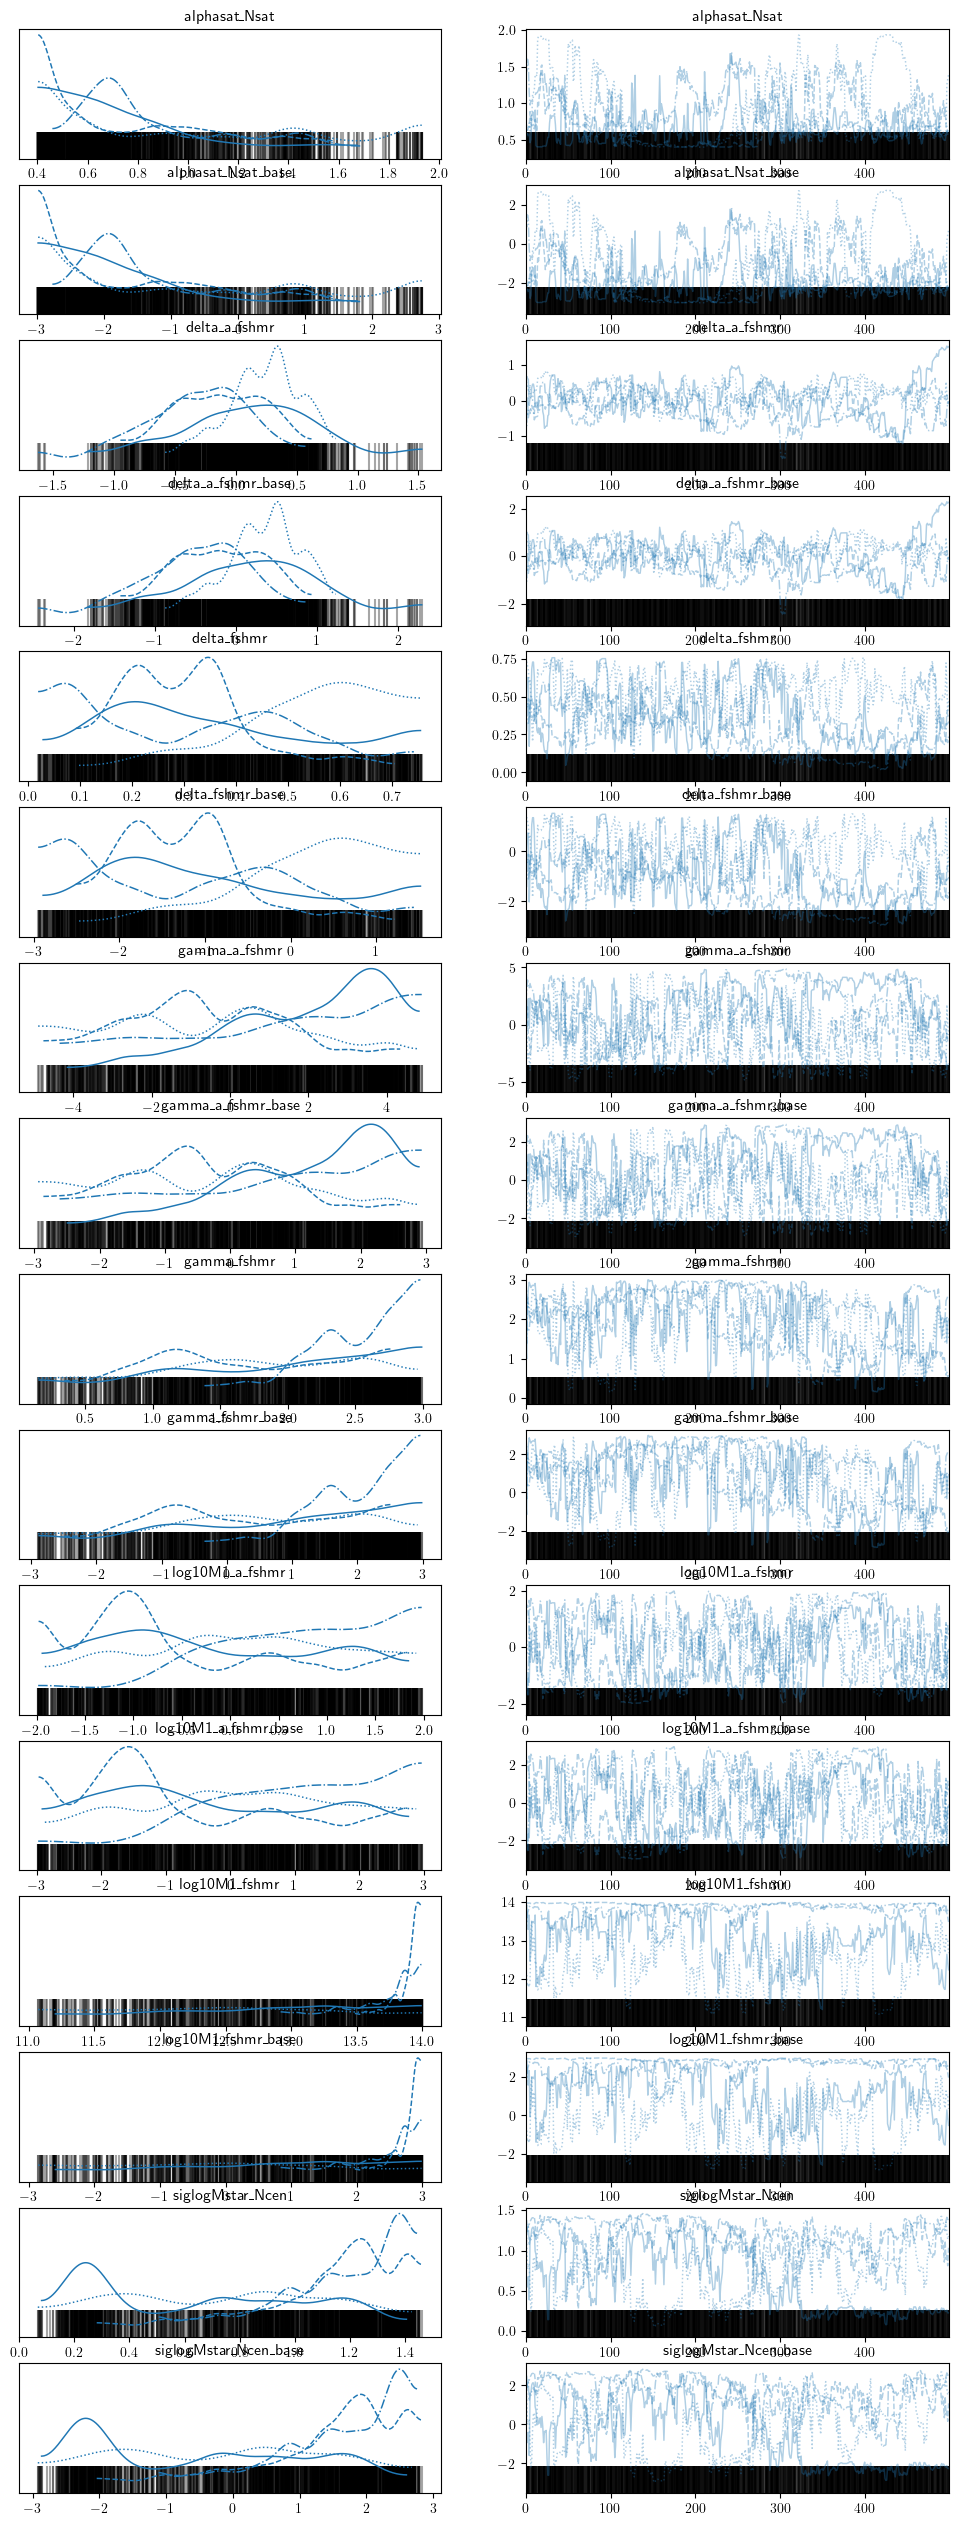

In [19]:
import arviz as az

data = az.from_numpyro(mcmc)
az.plot_trace(data);



In [4]:
import yaml
import pathlib
curr_path = pathlib.Path().absolute()
abs_path_data = os.path.abspath(curr_path / "../../data/") 
abs_path_src = os.path.abspath(curr_path / "../../src/") 
abs_path_results = os.path.abspath(curr_path / "../../results/") 
abs_path_params = os.path.abspath(curr_path / "../../param_files/") 

from deepmerge import always_merger
def read_yaml(file_path):
    with open(file_path, 'r') as file:
        data = yaml.safe_load(file)
    return data

def generate_dicts(data):
    sim_params_dict = data.get('sim_params', {})
    halo_params_dict = data.get('halo_params', {})
    analysis_dict = data.get('analysis', {})
    other_params_dict = data.get('other_params', {})
    return sim_params_dict, halo_params_dict, analysis_dict, other_params_dict

default_data = read_yaml(abs_path_params + '/params_default.yaml')
# sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(default_data)
new_data = read_yaml(abs_path_params + '/Pge/params.yaml')
# new_data = read_yaml(abs_path_params + '/DESxACT/params_v0.yaml')
merged_data = always_merger.merge(default_data, new_data)

sim_params_dict, halo_params_dict, analysis_dict, other_params_dict = generate_dicts(merged_data)

# analysis_dict['beam_fwhm_arcmin'] = 1.4
df_nz_comoving = np.loadtxt(abs_path_data + '/pge/comoving_nz_bgs_lrg_DESIY3_key_zall.txt')
zarray_comoving = df_nz_comoving[:,0]
nz_comoving_orig = df_nz_comoving[:,1]
indsel = np.where(zarray_comoving < 0.4)[0]
nz_comoving = np.zeros_like(zarray_comoving)
nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
indsel = np.where(zarray_comoving > 0.4)[0]
nz_comoving[indsel] = nz_comoving_orig[indsel]*1.0
analysis_dict['nbar_gal_comoving_zarray'] = zarray_comoving
analysis_dict['nbar_gal_comoving_val'] = nz_comoving




from scipy.interpolate import interp1d
ks = np.geomspace(5e-2,50,15) # wavenumbers
zedges = np.array([0.1, 0.4, 0.6, 0.8,1.1])
zarray_lens = np.linspace(0.001, 1.6, 100)
nbins_lens = len(zedges) - 1

cosmo_params = sim_params_dict.get('cosmo')
cosmo_jax = Cosmology(
            Omega_c=cosmo_params['Om0'] - cosmo_params['Ob0'],
            Omega_b=cosmo_params['Ob0'],
            h=cosmo_params['H0'] / 100.,
            sigma8=cosmo_params['sigma8'],
            n_s=cosmo_params['ns'],
            Omega_k=0.,
            w0=cosmo_params['w0'],
            wa=0.
            )
scale_fac_a_array = 1.0 / (1.0 + zarray_lens)
chi_array = radial_comoving_distance(cosmo_jax, scale_fac_a_array)
dchi_dz_array = (const.c.value * 1e-3) / bkgrd.H(cosmo_jax, scale_fac_a_array)
nz_comoving_interp = interp1d(zarray_comoving, nz_comoving, fill_value=1e-20, bounds_error=False)
nz_comoving_zarray = nz_comoving_interp(zarray_lens)
nz_zarray = nz_comoving_zarray * (chi_array**2 * dchi_dz_array)
nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
nz_lens = {}
for jb in range(nbins_lens):
    nz_jb = np.zeros_like(nz_zarray)
    indsel = np.where((zarray_lens > zedges[jb]) & (zarray_lens < zedges[jb+1]))[0]
    nz_jb[indsel] = nz_zarray[indsel]
    norm_val = np.trapz(nz_jb, zarray_lens)
    nz_jb = nz_jb/norm_val
    nz_lens[jb] = nz_jb

nz_info_dict = {}
nz_info_dict['z_array_lens'] = zarray_lens
nz_info_dict['nbins_lens'] = nbins_lens
for ji in range(nz_info_dict['nbins_lens']):
    nz_info_dict['nz'+str(ji)] = np.maximum(nz_lens[ji], 1e-10)
analysis_dict['nz_lens_info_dict'] = nz_info_dict


from astropy.io import fits
df = fits.open(os.path.abspath(abs_path_data + '/forecast/lsst_simulate_Y1.fits'))
z_array = df['nz_source'].data['Z_MID']
nz_info_dict = {}
nz_info_dict['z_array_source'] = z_array
nz_info_dict['nbins'] = 5
for ji in range(nz_info_dict['nbins']):
    nz_info_dict['nz'+str(ji)] = np.maximum(df['nz_source'].data['BIN'+str(ji+1)], 1e-10)
analysis_dict['nz_source_info_dict'] = nz_info_dict
other_params_dict['Delta_z_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])
other_params_dict['mult_shear_bias_array'] = np.zeros(analysis_dict['nz_source_info_dict']['nbins'])

analysis_dict['angles_data_array'] = df['xip'].data['ANG'][0:20]


analysis_dict['k_array_survey'] = jnp.array(ks / (sim_params_dict['cosmo']['H0']/100.))

# lmin, lmax, dl_log_array = 80.0, 8800.0, 0.23025851
# l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
# dl_array = l_array_all[1:] - l_array_all[:-1]
# l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
# halo_params_dict['ell_array'] = jnp.array(l_array_survey)
# analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
# analysis_dict['dl_array_survey'] = jnp.array(dl_array)



lmin, lmax, dl_log_array = 10.0, 61000.0, 0.23025851
l_array_all = np.exp(np.arange(np.log(lmin), np.log(lmax), dl_log_array))
dl_array = l_array_all[1:] - l_array_all[:-1]
l_array_survey = (l_array_all[1:] + l_array_all[:-1]) / 2.
halo_params_dict['ell_array'] = jnp.array(l_array_survey)
analysis_dict['l_array_survey'] = jnp.array(l_array_survey)
analysis_dict['dl_array_survey'] = jnp.array(dl_array)


analysis_dict['yy_noise_ell_fname'] = os.path.abspath(abs_path_data + '/pge/Noise_fid_yy_beamed_1p4arcmin.txt')

Ngals_bins = []
Vol_Gpc3 = []
Vol_Mpch3_uw = []
z_cens = []
P0 = 9e3
fsky_DESIxDESI = analysis_dict['fsky_gg']
for jb in range(nbins_lens):
    nz_jb_only = np.copy(nz_comoving_zarray)
    indsel = np.where((zarray_lens < zedges[jb]) | (zarray_lens > zedges[jb+1]))[0]
    nz_jb_only[indsel] = 0.0
    nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)

    ntot_jb = nz_integrate*4*np.pi*fsky_DESIxDESI
    Ngals_bins.append(ntot_jb)

    zmean = np.trapz(zarray_lens*nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)/nz_integrate
    z_cens.append(zmean)

    fsky_nz = np.ones_like(zarray_lens)
    fsky_nz[indsel] = 0.0
    fsky_nz_desi = fsky_nz * (nz_jb_only*P0/(1 + nz_jb_only*P0))**2
    h3 = (sim_params_dict['cosmo']['H0'] / 100.0)**3
    Vol_Gpc3_comoving = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)  
    Vol_Mpch3_uw.append(Vol_Gpc3_comoving * (h3 * 1e9)) 
    Vol_Gpc3_comoving_desi = 4*np.pi*fsky_DESIxDESI*np.trapz(fsky_nz_desi * (chi_array**2)*dchi_dz_array, zarray_lens)/(h3 * 1e9)   

    Vol_Gpc3.append(Vol_Gpc3_comoving_desi)
    print(zedges[jb], zedges[jb+1], 'Total galaxies = {:.2f}'.format(ntot_jb), ' Vol:', Vol_Gpc3_comoving_desi, ' Vol UW:', Vol_Gpc3_comoving)
    # print('Bin {}: Total galaxies = {:.2f}'.format(jb, ntot_jb))
    

Ngals_bins, Vol_Gpc3, z_cens, Vol_Mpch3_uw = np.array(Ngals_bins), np.array(Vol_Gpc3), np.array(z_cens), np.array(Vol_Mpch3_uw)
    
    # Ngals_bins = 3.33*np.array([506905, 771875, 859824])
analysis_dict['nbar_lens_bins'] = Ngals_bins/(analysis_dict['fsky_gg']*41253*(60**2))

analysis_dict['symbolic_pk'] = True
analysis_dict['symbolic_hmf'] = True

analysis_dict['beam_fwhm_arcmin'] = 1.6

# analysis_dict['symbolic_pk'] = False
# analysis_dict['symbolic_hmf'] = False





0.1 0.4 Total galaxies = 2094335.24  Vol: 5.48821108191444  Vol UW: 6.757022497734736
0.4 0.6 Total galaxies = 2238124.27  Vol: 9.547174515203288  Vol UW: 14.001443720133244
0.6 0.8 Total galaxies = 3190997.73  Vol: 13.706697159070595  Vol UW: 20.176679206163698
0.8 1.1 Total galaxies = 3757239.75  Vol: 20.10026768637848  Vol UW: 44.15669439334733


/tmp/ipykernel_4039425/111409494.py:68: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_zarray = nz_zarray/(np.trapz(nz_zarray, zarray_lens))
/tmp/ipykernel_4039425/111409494.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm_val = np.trapz(nz_jb, zarray_lens)
/tmp/ipykernel_4039425/111409494.py:134: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nz_integrate = np.trapz(nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)
/tmp/ipykernel_4039425/111409494.py:139: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  zmean = np.trapz(zarray_lens*nz_jb_only*(chi_array**2)*dchi_dz_array, zarray_lens)/nz_integrate
/tmp/ipykernel_

In [5]:
base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
Pkz_test = get_Pkz(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Profiles_obj=profiles_test)

bg_z_array = Pkz_test.bg_kz_mat[5,indsel_chi2]
nbar_z_array = Pkz_test.nbarz[indsel_chi2]

print(bg_z_array, nbar_z_array)




NameError: name 'indsel_chi2' is not defined

In [8]:
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)

# Pkz_test.fstar_tot_mat[10,:]
# Pkz_test.by_kz_mat
# nbar_comoving_target
# Pkz_test.Pge_tot_mat



In [13]:
# Cls_test.Pge_tot_mat


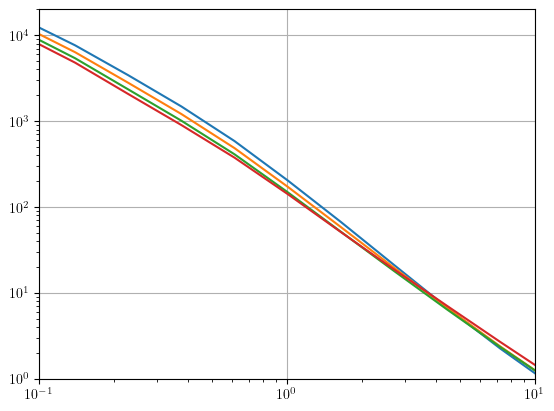

In [20]:
# Cls_test.Pge_tot_mat
h = 0.7
pl.figure()
for jb in range(4):
    # pl.plot(Cls_test.k_array_survey*h, (Cls_test.k_array_survey**2)*Cls_test.Pge_tot_mat[jb,:]/(h**2))
    pl.plot(Cls_test.k_array_survey*h, Cls_test.Pge_tot_mat[jb,:]/(h**3))    
pl.xscale('log')
pl.yscale('log')
pl.xlim(0.1, 10)
pl.ylim(1, 2e4)
pl.grid()




In [62]:
from tqdm import tqdm
from godmax.base_class import get_vmapped_func, get_vmapped_func_warg, EmptyCallable
from jax import jit, vmap
import interpax
import jax.scipy.integrate as jsi
from tqdm import tqdm
from colossus.cosmology import cosmology as cosmology_colossus
from colossus.halo import mass_defs
from colossus.halo import concentration
from scipy.interpolate import interp1d

vmapped_func = get_vmapped_func_warg(Pkz_test.get_P_1h, 2, 4)
Pyy_1h_kz_mat = vmapped_func(jnp.arange(Pkz_test.nk), jnp.arange(Pkz_test.nz), 3, 3).T
Pyy_2h_kz_mat = Pkz_test.by_kz_mat * Pkz_test.by_kz_mat * Pkz_test.plin_kz_mat
Pyy_tot_mat = Pyy_1h_kz_mat + Pyy_2h_kz_mat

print(profiles_test.fstar_tot_mat[10,:])
# Bl_array = jnp.exp(-1. * Pkz_test.ell_array * (Pkz_test.ell_array + 1) * (Pkz_test.sig_beam ** 2) / 2.)
# Bl_mat = Bl_array[:, None]

@jit
def get_P_lz(jl, jz, Pk_mat):
    ell = base_test.ell_array[jl]
    chi_z = base_test.chi_array[jz]
    k_ell = (ell + 0.5)/jnp.clip(chi_z, 1.0)
    Pkz_ell = jnp.exp(jnp.interp(jnp.log(k_ell), jnp.log(base_test.kPk_array), jnp.log(Pk_mat[:,jz])))
    return Pkz_ell

vmapped_func = get_vmapped_func_warg(get_P_lz, 2, 3)
Pkyy_lz_mat = vmapped_func(jnp.arange(base_test.nell), jnp.arange(base_test.nz), Pyy_tot_mat).T

# Pkyy_lz_mat = Pkyy_lz_mat * (Bl_mat**2)
logPkyylz_2d_interp = interpax.Interpolator2D(jnp.log(base_test.ell_array), base_test.z_array, jnp.log(Pkyy_lz_mat), extrap=True)        

@jit
def get_Cl_tot(jl):
    Pk = jnp.exp(logPkyylz_2d_interp(jnp.log(base_test.ell_array[jl]), base_test.z_array_for_Cls))
    Wy_array = (1.0 / (1.0 + base_test.z_array_for_Cls))

    prefac = Wy_array / (base_test.chi_array_for_Cls**2)
    fx = prefac * prefac  * (base_test.chi_array_for_Cls ** 2) * base_test.dchi_dz_array_for_Cls * Pk
    return jsi.trapezoid(fx, x=base_test.z_array_for_Cls)     

Cl_yy = vmap(get_Cl_tot)(jnp.arange(base_test.nell))
fach = 1e12*((base_test.ell_array)*(base_test.ell_array + 1) / (2 * np.pi))
# if np.abs((fach*Cl_yy)[np.argmin(np.abs(base_test.ell_array - 3000))] - 1e12*3.42*fac)/(1e12*3.42*fac) < 0.2:
jz_fb = 50
if True:

    cosmop = sim_params_dict['cosmo']
    params = {'w0':-1.0 ,'flat': True, 'H0': cosmop['H0'], 'Om0': cosmop['Om0'], 'Ob0': cosmop['Ob0'], 'sigma8':cosmop['sigma8'] ,'ns': cosmop['ns']}
    cosmology_colossus.addCosmology('myCosmo', params)
    cosmology_colossus.setCosmology('myCosmo')
    cosmo_colossus = cosmology_colossus.setCosmology('myCosmo')
    
    h = params['H0']/100.
    z = z_array[jz_fb]
    M500c_min_wh = 6e13*h
    M500c_max_wh = 2e14*h
    c500c_min_wh = concentration.concentration(M500c_min_wh, '500c', z, model = 'bhattacharya13')
    c500c_max_wh = concentration.concentration(M500c_max_wh, '500c', z, model = 'bhattacharya13')
    M200c_min_wh, _, _ = mass_defs.changeMassDefinition(M500c_min_wh, c500c_min_wh, z, '500c', '200c')
    M200c_max_wh, _, _ = mass_defs.changeMassDefinition(M500c_max_wh, c500c_max_wh, z, '500c', '200c')
    
    halo_params_dict['lg10_Mmin'] = np.log10(M200c_min_wh)
    halo_params_dict['lg10_Mmax'] = np.log10(M200c_max_wh)
    
    halo_params_dict['zmin'] = z
    halo_params_dict['zmax'] = z + 0.01
    halo_params_dict['nz'] = 3

    halo_params_dict['nr'] = 32
    
    base_test = base_class(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict)
    profiles_test = Profiles(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, base_class_obj=base_test)
    
    
    M200c_array = profiles_test.M_array
    conc_array = profiles_test.conc_Mz_mat[0,:]
    M500c_array, R500c_array, _ = mass_defs.changeMassDefinition(M200c_array, conc_array, z, '200c', '500c')
    R500c_array /= 1000.
    
    rho_baryon_mat = profiles_test.rho_gas_mat + profiles_test.rho_cga_mat + ((profiles_test.fstar_sat_mat/profiles_test.fclm_mat)[None,:,:])*profiles_test.rho_clm_mat
    rho_tot_mat = profiles_test.rho_dmb_mat
    rho_baryon_mat_z0 = rho_baryon_mat[:,0,:]
    rho_tot_mat_z0 = rho_tot_mat[:,0,:]
    
    fb_array = np.zeros(len(M500c_array))
    for jM in range(len(M500c_array)):
            r500_jM = R500c_array[jM]
            r_array_jM = np.logspace(-3, np.log10(r500_jM), 100)
            rho_baryon_jM = rho_baryon_mat_z0[:,jM]
            interprho = interp1d(np.log(profiles_test.r_array), np.log(rho_baryon_jM), fill_value='extrapolate')
            rhob_jM = np.exp(interprho(np.log(r_array_jM)))
            rhob_int_jM = np.trapezoid(4 * np.pi * r_array_jM**3 * rhob_jM, np.log(r_array_jM))
    
    
            rho_tot_jM = rho_tot_mat_z0[:,jM]
            interprho = interp1d(np.log(profiles_test.r_array), np.log(rho_tot_jM), fill_value='extrapolate')
            rhotot_jM = np.exp(interprho(np.log(r_array_jM)))
            rhotot_int_jM = np.trapezoid(4 * np.pi * r_array_jM**3 * rhotot_jM, np.log(r_array_jM))
    
            fb_array[jM] = rhob_int_jM/rhotot_int_jM
    
    fb_bar = np.trapezoid(fb_array * profiles_test.hmf_Mz_mat[0, :], x=np.log(profiles_test.M_array))/np.trapezoid(profiles_test.hmf_Mz_mat[0, :], x=np.log(profiles_test.M_array))
    fb_bar_norm = fb_bar/(cosmop['Ob0']/cosmop['Om0'])

    # fb_norm_all_samp.append(fb_bar_norm)
    

    # print(map_ind, z, fb_bar_norm, sim_params_dict)
    print(z, fb_bar_norm, sim_params_dict)


    # Cl_yy_all_samp.append(Cl_yy)
    # ratio = Pkz_test.Pmm_dmb_tot_mat[:,0]/Pkz_test.Pmm_nfw_tot_mat[:,0]    
    # Pmm_ratio_all_samp.append(savitzky_golay(ratio, 19, 3))




[0.00263194 0.00631108 0.00817349 0.00856857 0.00800747 0.00721805
 0.00631196 0.00551291 0.00486428 0.00439163 0.00416523 0.00416312
 0.00440952 0.00488845 0.00562514 0.00658471 0.00781032 0.00926291
 0.01098683 0.01292896 0.01516884 0.01759513 0.02032782 0.02329465]
0.5 0.2603345909673316 {'cosmo': {'flat': True, 'H0': 67.2, 'Om0': 0.3, 'Ob0': 0.048, 'sigma8': 0.8, 'ns': 0.96, 'w0': -1.0}, 'init_power': True, 'nfw_trunc': True, 'epsilon_rt': 4.0, 'theta_ej_0': 2.0, 'log10_Mstar0_theta_ej': 16.0, 'nu_theta_ej_M': -0.33, 'nu_theta_ej_z': -1.22, 'theta_co_0': 0.05, 'log10_Mstar0_theta_co': 16.0, 'nu_theta_co_M': 0.0, 'nu_theta_co_z': 0.0, 'mu_beta': 0.0762, 'log10_Mstar0': 14.0, 'log10_Mc0': 13.75, 'nu_z': 0.0, 'nu_M': 0.0, 'gamma_rhogas': 2.0, 'delta_rhogas': 7.0, 'a_zeta': 0.3, 'n_zeta': 2.0, 'alpha_nt': 0.05, 'beta_nt': 0.5, 'n_nt': 0.3, 'log10M1_fshmr': 12.55, 'log10M1_a_fshmr': 0.38, 'log10Mstar0_fshmr': 10.72, 'log10Mstar0_a_fshmr': 0.55, 'beta_fshmr': 0.4, 'beta_a_fshmr': 0.2, 'd

In [63]:
Cl_yy


Array([2.49519724e-16, 2.19952109e-16, 1.85646013e-16, 1.49899105e-16,
       1.18511346e-16, 9.34939841e-17, 7.25417633e-17, 5.70722176e-17,
       4.56513466e-17, 3.71630785e-17, 3.03983353e-17, 2.48316812e-17,
       2.01693564e-17, 1.62338334e-17, 1.27808978e-17, 9.93164363e-18,
       7.64213646e-18, 5.79790707e-18, 4.29882078e-18, 3.13033451e-18,
       2.22590406e-18, 1.53742560e-18, 1.02271375e-18, 6.52998128e-19,
       3.96761098e-19, 2.28564824e-19, 1.23769486e-19, 6.27317518e-20,
       2.97723972e-20, 1.32678089e-20, 5.55159104e-21, 2.19622854e-21,
       8.26549516e-22, 2.97350106e-22, 1.02266760e-22, 3.37554785e-23,
       1.07468306e-23], dtype=float64)

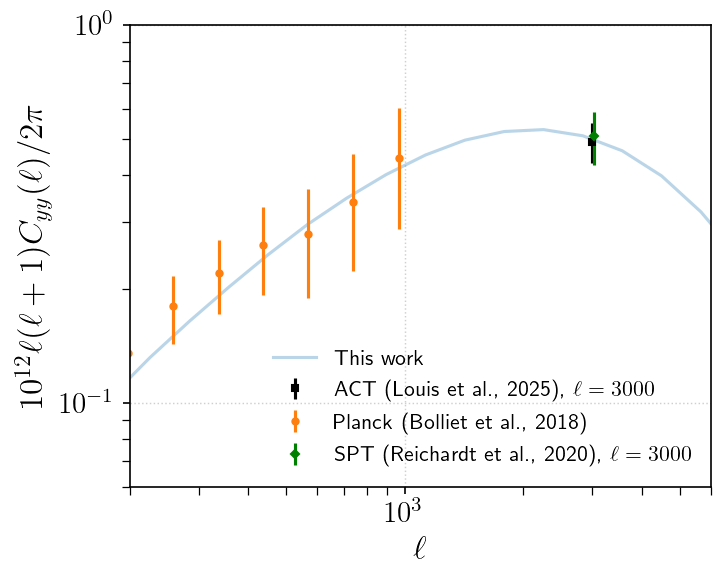

In [64]:
import matplotlib.pyplot as plt
%matplotlib inline

import numpy as np
from astropy import constants as const
from astropy import units as u

def get_Tcmb_K():
    Tcmb = 2.7255
    return Tcmb

def tsz_freq(nu):
    #Input frequency in GHz, output conversion from y to \Delta T/T_CMB
    #nu in GHz
    #See carlstrom paper: https://ned.ipac.caltech.edu/level5/Sept05/Carlstrom/Carlstrom2.html
    T_cmb = get_Tcmb_K()*u.K
    x = (const.h*nu*(1.0e9*1./u.s)/(const.k_B*T_cmb)).to('').value
    f_x = x*((np.exp(x) + 1.)/(np.exp(x) - 1.)) - 4.
    return f_x

fac = (1e-12)/(((get_Tcmb_K())*tsz_freq(150))**2)

fnameDl_yy_planck = np.loadtxt(abs_path_data + '/DESxACT/Cl_yy_data/bolliet_18_cl_yy_mean.txt')
ell = fnameDl_yy_planck[:,0]
Dl_yy_planck = fnameDl_yy_planck[:,1] * 1e-12

fnameDl_yy_planck = np.loadtxt(abs_path_data + '/DESxACT/Cl_yy_data/bolliet_18_cl_yy_meanp1sig.txt')
err_Dlyy_planck = (fnameDl_yy_planck[:,1] * 1e-12 - Dl_yy_planck)


act_Dl_ratio = np.loadtxt(abs_path_data + '/DESxACT/Cl_yy_data/ACT_DR6_Dlyy_ratio_3000.txt')
ell_act_Dl_ratio = act_Dl_ratio[:,0]
Dl_ratio_act = act_Dl_ratio[:,1]

# fac = (1e-12)/(((get_Tcmb_K())*tsz_freq(150))**2)


plt.figure(figsize=(5, 4), dpi=150)

# Fill region with transparency
# plt.fill_between(M_array, Ymin, Ymax, alpha=0.3, color='tab:blue', label='This Work')
plt.plot(base_test.ell_array, fach*Cl_yy, color='tab:blue', alpha=0.3, label='This work')
# plt.fill_between(M_array, Ymin_2sigma, Ymax_2sigma, alpha=0.2, color='tab:blue')

# Plot main curve with improved styling
vljv,vljvp, vljvn = 3.3*fac,(3.3+0.4)*fac,(3.3-0.4)*fac
plt.errorbar(np.array([3000.]),1e12*np.array([vljv]),yerr=1e12*np.array([[vljv-vljvn,vljvp - vljv]]).T,ls='',marker='s',ms='3',color='black',label=r'ACT (Louis et al., 2025), $\ell=3000$')
# plt.plot(ell_act_Dl_ratio, 1e12*Dl_ratio_act*3.3*fac, ls='--', color='black', label='ACT (Louis et al., 2025) bestfit')
plt.errorbar(ell, 1e12*Dl_yy_planck, yerr=1e12*err_Dlyy_planck, ls='', marker='o', ms='3', color='tab:orange', label='Planck (Bolliet et al., 2018)')
vljv,vljvp, vljvn = 3.42*fac,(3.42+0.54)*fac,(3.42-0.54)*fac
plt.errorbar([3024],[1e12*vljv],yerr=1e12*np.array([[vljv-vljvn,vljvp - vljv]]).T,ls='',marker='D',ms='3',color='green',label=r'SPT (Reichardt et al., 2020), $\ell=3000$')



# Log scales for better visualization
plt.xscale('log')
plt.yscale('log')

# Axis labels with LaTeX-style formatting
plt.xlabel(r'$\ell$', fontsize=16)
plt.ylabel(r'$10^{12} \ell (\ell + 1) C_{yy}(\ell)/2\pi$', fontsize=16)

# Improved axis limits
plt.ylim(1e12*6e-14, 1e11*1e-11)
plt.xlim(2e2, 6e3)

# Improved legend with frame and better positioning
plt.legend(fontsize=10.5, frameon=False, loc='best')

# Better tick formatting for readability
plt.tick_params(axis='both', which='major', labelsize=14)
plt.tick_params(axis='both', which='minor', labelsize=12, length=4)

# Grid with transparency for better visualization
# plt.grid(True, which="both", linestyle=":", linewidth=0.7, alpha=0.6)
plt.grid(True, linestyle=":", linewidth=0.7, alpha=0.6)

# Save figure with high quality
# sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# plt.savefig(sdir + 'Dl_yy_infer.pdf', bbox_inches='tight', dpi=300) 

plt.show()




In [65]:
Cls_test = get_Cl(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Pkz_obj=Pkz_test)
xis_test = get_xi(sim_params_dict, halo_params_dict, analysis_dict, other_params_dict, Cl_obj=Cls_test)


from godmax.base_class import get_vmapped_func, get_vmapped_func_warg, EmptyCallable
import interpax
import jax.scipy.integrate as jsi
from mcfitjax.transforms import Hankel

Bl_mat = (jnp.exp(-1. * Pkz_test.ell_array * (Pkz_test.ell_array + 1) * (Pkz_test.sig_beam ** 2) / 2.))[:, None]
def get_xi_pred(Pk_mat, isym, ismm_p, ismm_m):
    # Convert the 3D power spectra multipole space Pkz_ell:
    vmapped_func = get_vmapped_func_warg(Cls_test.get_P_lz, 2, 3)
    Pk_lz_mat = vmapped_func(jnp.arange(Pkz_test.nell), jnp.arange(Pkz_test.nz), Pk_mat).T    
    if isym:
        Pk_lz_mat = Pk_lz_mat * Bl_mat
    logPklz_2d_interp = interpax.Interpolator2D(jnp.log(Pkz_test.ell_array), Pkz_test.z_array, jnp.log(Pk_lz_mat), extrap=True)        
    
    def get_Cl_tot(jl, jb1, jb2, probe1, probe2): 
        # Handle the first probe condition
        def compute_prefac(probe, jb):
            conditions = [
                (probe == 0, (1. + Cls_test.mult_shear_bias_array[jb]) * (Cls_test.Wk_mat[jb] / (Cls_test.chi_array_for_Cls**2))),
                (probe == 3, Cls_test.Wy_array / (Cls_test.chi_array_for_Cls**2)),
            ]
            
            prefac = jnp.nan
            for condition, value in conditions:
                prefac = jnp.where(condition, value, prefac)
            return prefac
    
        # Compute prefactors for probe1 and probe2
        prefac_for_uk1 = compute_prefac(probe1, jb1)
        prefac_for_uk2 = compute_prefac(probe2, jb2)        
    
        Pk = jnp.exp(logPklz_2d_interp(jnp.log(Cls_test.ell_array[jl]), Cls_test.z_array_for_Cls))
        fx = prefac_for_uk1 * prefac_for_uk2  * (Cls_test.chi_array_for_Cls ** 2) * Cls_test.dchi_dz_array_for_Cls * Pk
        return jsi.trapezoid(fx, x=Cls_test.z_array_for_Cls)  
        
    
    if isym:
        vmapped_func = get_vmapped_func_warg(get_Cl_tot, 2, 5)
        Cl_mat = vmapped_func(jnp.arange(Cls_test.nell), jnp.arange(Cls_test.nbins), 0, 0, 3).T
        theta_out, xi_out = (Hankel(Cls_test.ell_array, nu=2, q=1.0, nx=Cls_test.nell, lowring=True)(Cl_mat, axis=0, extrap=False))
        theta_out_arcmin = theta_out * (180. / jnp.pi) * 60.
        gty_tot_mat = jnp.array(xi_out * (1 / (2 * jnp.pi)))
        
        def interp_gty_theta(jt, jb):
            gty_out = jnp.exp(jnp.interp(jnp.log(xis_test.angles_data_array[jt]), jnp.log(theta_out_arcmin), jnp.log(gty_tot_mat[:, jb])))
            return gty_out

        xi_out_mat = get_vmapped_func(interp_gty_theta, 2)(jnp.arange(xis_test.nt_out), jnp.arange(xis_test.nbins)).T
        
    
    else:
        vmapped_func = get_vmapped_func_warg(get_Cl_tot, 3, 5)
        Cl_mat = vmapped_func(jnp.arange(Cls_test.nell), jnp.arange(Cls_test.nbins), jnp.arange(Cls_test.nbins), 0, 0).T
        if ismm_p:
            theta_out, xi_out = (Hankel(xis_test.ell_array, nu=0, q=1.0, nx=xis_test.nell, lowring=True)(Cl_mat, axis=0, extrap=False))        
        if ismm_m:
            theta_out, xi_out = (Hankel(xis_test.ell_array, nu=4, q=1.0, nx=xis_test.nell, lowring=True)(Cl_mat, axis=0, extrap=False))        
        theta_out_arcmin = theta_out * (180. / jnp.pi) * 60.
        xi_tot_mat = jnp.array(xi_out * (1 / (2 * jnp.pi)))
        def interp_xipm_theta(jb1, jb2):
            xi_out = jnp.exp(jnp.interp(jnp.log(xis_test.angles_data_array), jnp.log(theta_out_arcmin), jnp.log(xi_tot_mat[:, jb1,jb2])))
            return xi_out
        xi_out_mat = get_vmapped_func(interp_xipm_theta, 2)(jnp.arange(xis_test.nbins), jnp.arange(xis_test.nbins)).T

    return xi_out_mat
    

gty_1h_ym = get_xi_pred(Pkz_test.Pym_1h_kz_mat, 1, 0, 0)
gty_2h_ym = get_xi_pred(Pkz_test.Pym_2h_kz_mat, 1, 0, 0)

deproj_to_true_y_file = {
    'None': 'ilc_SZ_yy',
    'cib_1p0': 'ilc_SZ_deproj_cib_1.0_10.7_yy',
    'cib_1p2': 'ilc_SZ_deproj_cib_1.2_10.7_yy',
    'cib_1p4': 'ilc_SZ_deproj_cib_1.4_10.7_yy',
    'cib_1p6': 'ilc_SZ_deproj_cib_1.6_10.7_yy',
    'cib_1p7': 'ilc_SZ_deproj_cib_1.7_10.7_yy',
    'cib_1p8': 'ilc_SZ_deproj_cib_1.8_10.7_yy',
    'cib_2p0': 'ilc_SZ_deproj_cib_2.0_10.7_yy',
    'cib_1p0_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.0_10.7_yy',
    'cib_1p2_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.2_10.7_yy',
    'cib_1p4_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.4_10.7_yy',
    'cib_1p6_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.6_10.7_yy',
    'cib_1p7_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.7_10.7_yy',
    'cib_1p8_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_1.8_10.7_yy',
    'cib_2p0_dBeta': 'ilc_SZ_deproj_cib_cibdBeta_2.0_10.7_yy',
}
deproj = 'cib_1p7_dBeta'
probe = 'all'
# save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v2/')
# save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v3/')
save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v4/')
# df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}.pk', 'rb'))
# df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}_maskedPS_maskang_3_5sigma_thresh.pk', 'rb'))
df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}_maskedPS.pk', 'rb'))
cov_total = df_measure['cov_total']
xi_all = df_measure['xi_all']
theta_all = df_measure['theta_all']
bin1_all = df_measure['bin1_all']
bin2_all = df_measure['bin2_all']
cov_total = jnp.array(cov_total)
data_vec = jnp.array(xi_all)

# save_DV_dir = os.path.abspath(abs_path_data + '/DESxACT/DV_v2/')
# df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}.pk', 'rb'))
# df_measure = pk.load(open(f'{save_DV_dir}/DESxACT_gty_xip_xim_DV_{deproj_to_true_y_file[deproj]}_maskedPS_maskang_3_5sigma_thresh.pk', 'rb'))
# cov_total = df_measure['cov_total']
# xi_all = df_measure['xi_all']
# theta_all = df_measure['theta_all']
# cov_total = jnp.array(cov_total)
# data_vec = jnp.array(xi_all)

df_cs = fits.open(abs_path_data + '/DESxACT/2pt_NG_final_2ptunblind_02_26_21_wnz_maglim_covupdate_newbins.fits') 
bin1_vals =  df_cs['xip'].data['BIN1'][::20]
bin2_vals =  df_cs['xip'].data['BIN2'][::20]
biny_vals = np.array([1,2,3,4])
ang_vals = df_cs['xip'].data['ANG'][0:20]



cov_total = jnp.array(cov_total)
data_vec = jnp.array(xi_all)


gty_dv = data_vec[:80]
sig_gty_dv = np.sqrt(np.diag(cov_total))[:80]

xip_dv = data_vec[80:280]
sig_xip_dv = np.sqrt(np.diag(cov_total))[80:280]
bin1_xip_dv = df_cs['xip'].data['BIN1']
bin2_xip_dv = df_cs['xip'].data['BIN2']

xim_dv = data_vec[280:]
sig_xim_dv = np.sqrt(np.diag(cov_total))[280:]
bin1_xim_dv = df_cs['xim'].data['BIN1']
bin2_xim_dv = df_cs['xim'].data['BIN2']

if probe == 'xip_xim':
    cov_total = cov_total[80:, 80:]
    data_vec = data_vec[80:]
elif probe == 'gty':
    cov_total = cov_total[:80, :80]
    data_vec = data_vec[:80]

fname = abs_path_data + '/DESxACT/scale_cuts_xipm_y3_gty_fid.ini'
config = configobj.ConfigObj(fname)
sc_xipm = config['shear-shear']
sc_gty = config['shear-tsz']



def process_indices(num, bin1_vals, bin2_vals, angle_ranges, offset, probe, angle_type, do_scalecuts):
    indices, indrm = [], []
    for js in range(num):
        binv, thetav = divmod(js, 20)
        bin1, bin2 = (bin1_vals[binv] - 1, bin2_vals[binv] - 1) if angle_type != 'gty' else (None, None)
        if do_scalecuts:
            sc_min, sc_max = map(float, angle_ranges[binv].split())
        else:
            sc_min, sc_max = 1e-3, 999.0
        if sc_min < ang_vals[thetav] < sc_max:
            indices.append([int(thetav), int(bin1), int(bin2)] if bin1 is not None else [int(thetav), int(binv)])
        elif probe in [angle_type, 'all']:
            indrm.append(int(offset + js))
    return jnp.array(indices, dtype=jnp.int32), jnp.array(indrm, dtype=jnp.int32)

# Process gty indices
sc_ranges_gty = [sc_gty[f'angle_range_gty_{biny}_0'] for biny in biny_vals]
index_gty, indrm_gty = process_indices(80, None, None, sc_ranges_gty, 0, probe, 'gty', False)
len_ind_gty = len(index_gty)
# Process xip indices
sc_ranges_xip = [sc_xipm[f'angle_range_xip_{bin1}_{bin2}'] for bin1, bin2 in zip(bin1_vals, bin2_vals)]
offset_xip = 80 if probe in ['gty', 'all'] else 0
index_xip, indrm_xip = process_indices(200, bin1_vals, bin2_vals, sc_ranges_xip, offset_xip, probe, 'xip_xim', False)
len_ind_xip = len(index_xip)
# Process xim indices
sc_ranges_xim = [sc_xipm[f'angle_range_xim_{bin1}_{bin2}'] for bin1, bin2 in zip(bin1_vals, bin2_vals)]
offset_xim = 280 if probe in ['gty', 'all'] else 200
index_xim, indrm_xim = process_indices(200, bin1_vals, bin2_vals, sc_ranges_xim, offset_xim, probe, 'xip_xim', False)
len_ind_xim = len(index_xim)


def get_gty_from_index(index):
    index_val = index_gty[index]
    return xis_test.gty_out_mat[index_val[0], index_val[1]]

def get_xip_from_index(index):
    index_val = index_xip[index]
    return xis_test.xip_out_mat[index_val[0], index_val[1], index_val[2]]

def get_xim_from_index(index):
    index_val = index_xim[index]
    return xis_test.xim_out_mat[index_val[0], index_val[1], index_val[2]]

gty_all = vmap(get_gty_from_index)(jnp.arange(len_ind_gty))
xip_all = vmap(get_xip_from_index)(jnp.arange(len_ind_xip))
xim_all = vmap(get_xim_from_index)(jnp.arange(len_ind_xim))







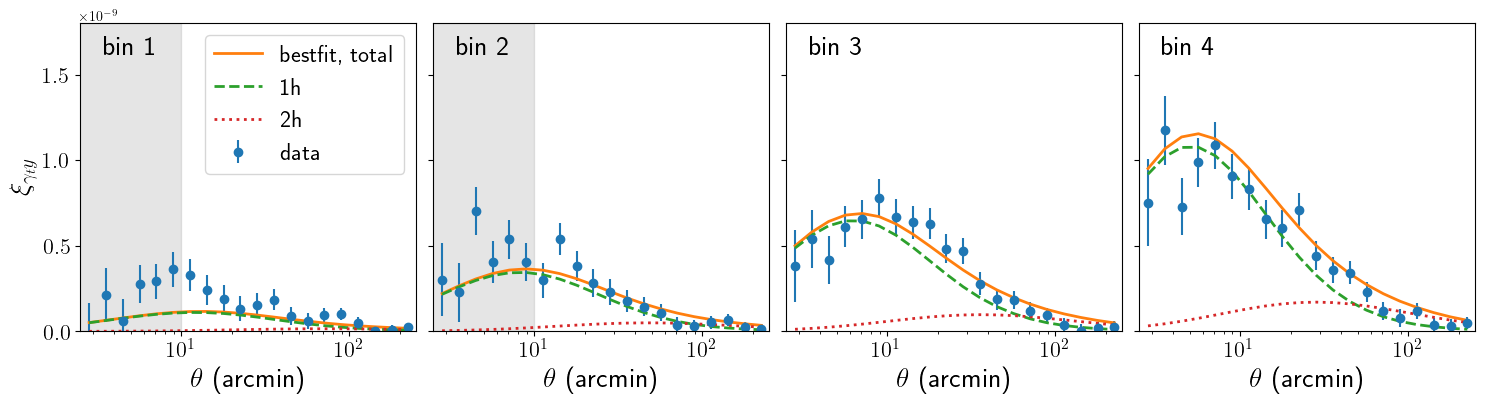

In [66]:
# make a four subplot figure:
fig, axes = pl.subplots(1, 4, figsize=(18, 4), sharex=True, sharey=True)
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji in range(4):
    ax = axes[ji]
    ax.errorbar(theta_all[ji*20:(ji+1)*20], gty_dv[ji*20:(ji+1)*20], sig_gty_dv[ji*20:(ji+1)*20], label='data', ls='', marker='o')
    ax.plot(theta_all[ji*20:(ji+1)*20], gty_all[ji*20:(ji+1)*20], label='bestfit, total', lw=2)
    ax.plot(theta_all[ji*20:(ji+1)*20], gty_1h_ym[:, ji], label='1h', ls='--', lw=2)
    ax.plot(theta_all[ji*20:(ji+1)*20], gty_2h_ym[:, ji], label='2h', ls=':', lw=2)
    # ax.set_title(f'gty bin {ji+1}')
    if ji == 0:
        ax.legend(fontsize=17)
    ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_ylim(0, 1.8e-9)
    ax.set_xlabel(r'$\theta$ (arcmin)', fontsize=20)

    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.tick_params(axis='both', which='minor', labelsize=16)
    ax.set_xlim(2.5, 250)
    ax.text(0.07, 0.9, f'bin {ji+1}', transform=ax.transAxes, fontsize=20)
    if ji == 0:
        ax.set_ylabel(r'$\xi_{\gamma_t y}$', fontsize=20)

    if ji < 2:
        ax.axvspan(0, 10, color='gray', alpha=0.2)
    # ax.set_xlim(0, 20)
sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# fig.savefig(sdir + 'gty_dv_v12.pdf', bbox_inches='tight', dpi=300)
pl.show()









In [68]:
xip_1h_ym = get_xi_pred(Pkz_test.Pmm_dmb_1h_kz_mat, 0, 1, 0)
xip_2h_ym = get_xi_pred(Pkz_test.Pmm_dmb_2h_kz_mat, 0, 1, 0)
xip_hf_ym = get_xi_pred(Pkz_test.phfit_kz_mat, 0, 1, 0)



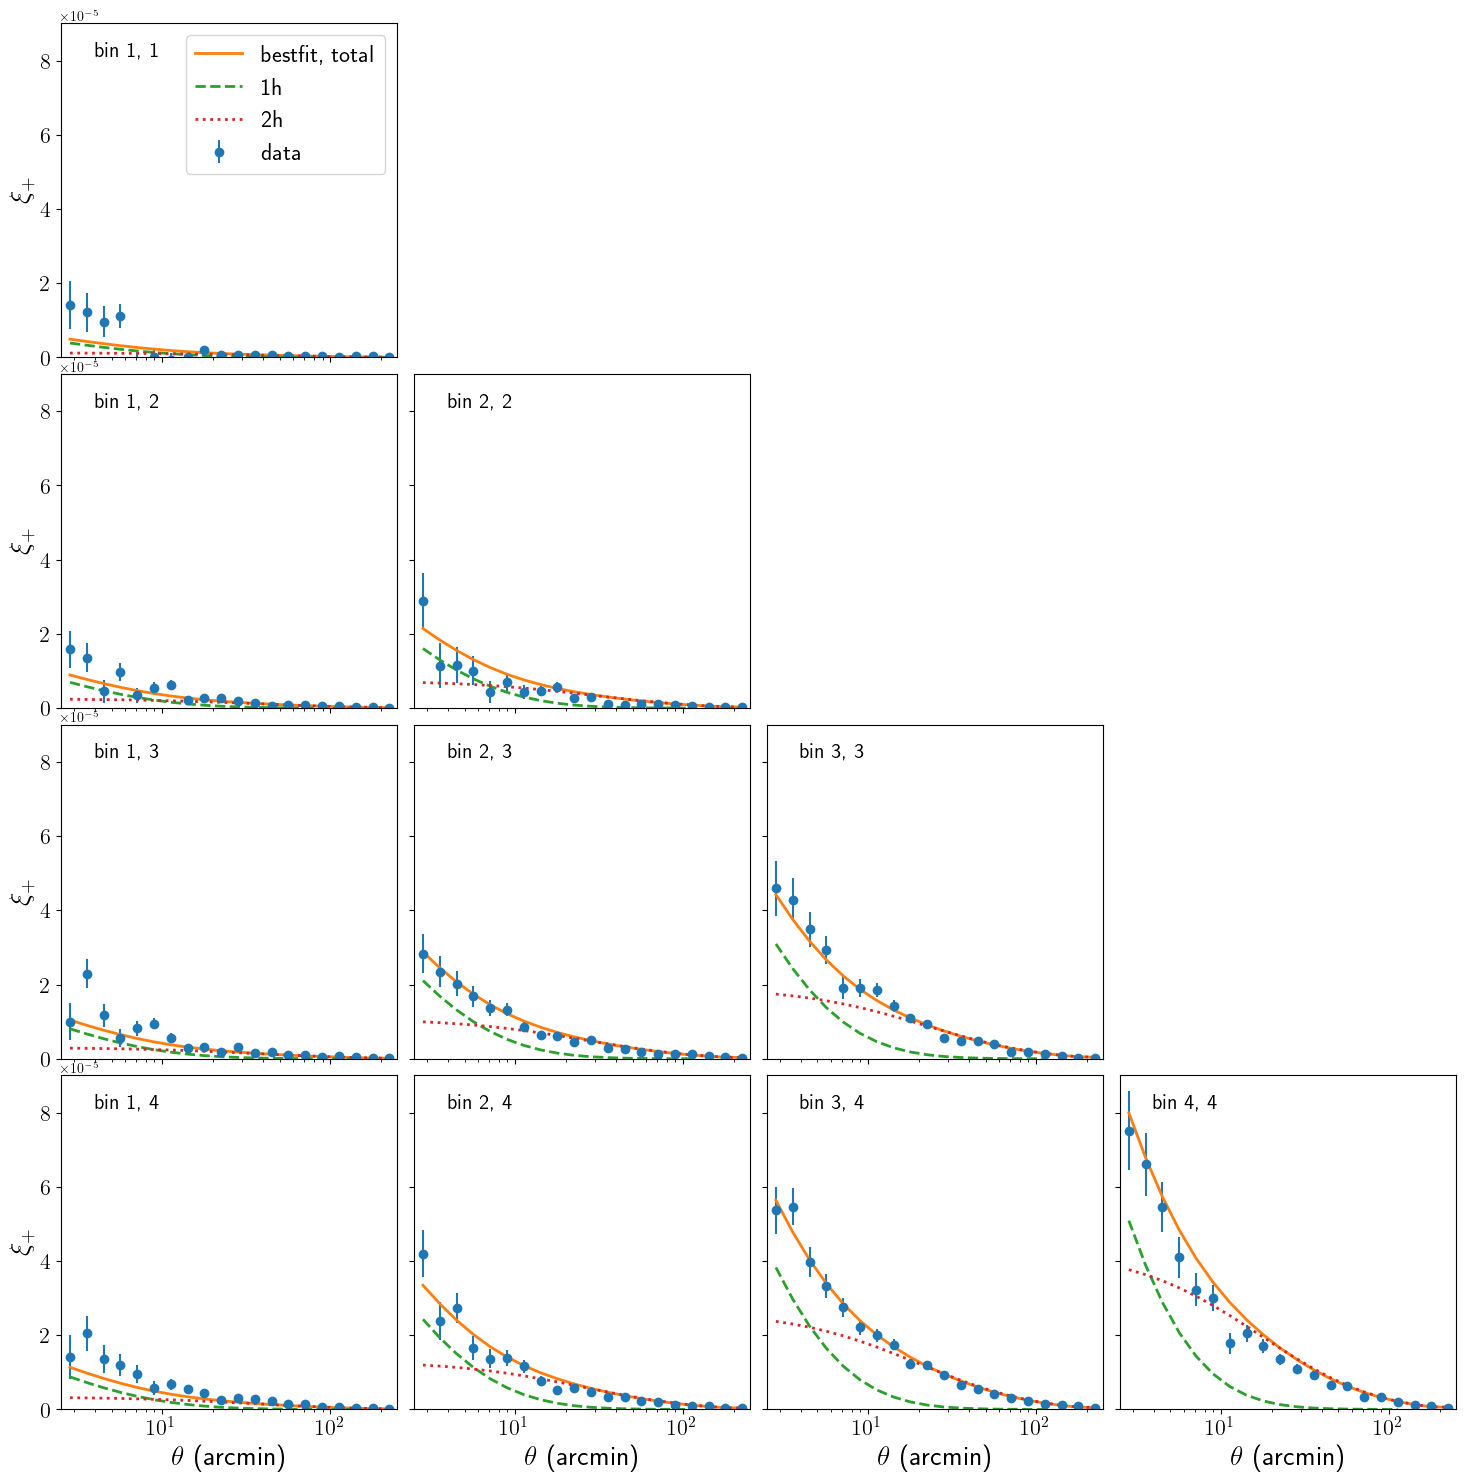

In [70]:
# make a four subplot figure:
theta_xip = theta_all[80:280]
theta_xim = theta_all[280:]
fig, axes = pl.subplots(4, 4, figsize=(18, 18), sharex=True, sharey=True)
# set spacing between suplots:
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji1 in range(4):
    for ji2 in range(4):
        if ji1 <= ji2:
            ax = axes[ji2, ji1]
            indsel = np.where((bin1_xip_dv == ji1+1) & (bin2_xip_dv == ji2+1))[0]
            ax.errorbar(theta_xip[indsel], xip_dv[indsel], sig_xip_dv[indsel], label='data', ls='', marker='o')
            ax.plot(theta_xip[indsel], xip_all[indsel], label='bestfit, total', lw=2)
            ax.plot(theta_xip[indsel], xip_1h_ym[:,ji1, ji2], label='1h', lw=2, ls='--')
            ax.plot(theta_xip[indsel], xip_2h_ym[:,ji1, ji2], label='2h', lw=2, ls=':')
            # ax.plot(theta_xip[indsel], xip_hf_ym[:,ji1, ji2], label='Halofit', lw=2, ls='-.')
            # ax.set_title(f'gty bin {ji+1}')
            if ji1 == 0 and ji2 == 0:
                # ax.set_title('xim')
                ax.legend(fontsize=17)
            ax.set_xscale('log')
            # ax.set_yscale('log')
            ax.set_ylim(0, 9e-5)
            ax.set_xlim(2.5, 250)
            ax.text(0.1, 0.9, f'bin {ji1+1}, {ji2+1}', transform=ax.transAxes, fontsize=15)
            if ji2 == 3:
                ax.set_xlabel(r'$\theta$ (arcmin)', fontsize=20)
            if ji1 == 0:
                ax.set_ylabel(r'$\xi_{+}$', fontsize=20)
            ax.tick_params(axis='both', which='major', labelsize=16)
            ax.tick_params(axis='both', which='minor', labelsize=16)

            # if ji < 2:
                # ax.axvspan(0, 10, color='gray', alpha=0.2)
        else:
            # delete the subplot:
            fig.delaxes(axes[ji2, ji1])
    # ax.set_xlim(0, 20)
# fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xip_dv.png', bbox_inches='tight', dpi=300)
# sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# fig.savefig(sdir + 'xip_dv_v10.pdf', bbox_inches='tight', dpi=300)
# fig.savefig(sdir + 'xip_dv_v12.pdf', bbox_inches='tight', dpi=300)
pl.show()



In [72]:
xim_1h_ym = get_xi_pred(Pkz_test.Pmm_dmb_1h_kz_mat, 0, 0, 1)
xim_2h_ym = get_xi_pred(Pkz_test.Pmm_dmb_2h_kz_mat, 0, 0, 1)
xim_hf_ym = get_xi_pred(Pkz_test.phfit_kz_mat, 0, 0, 1)




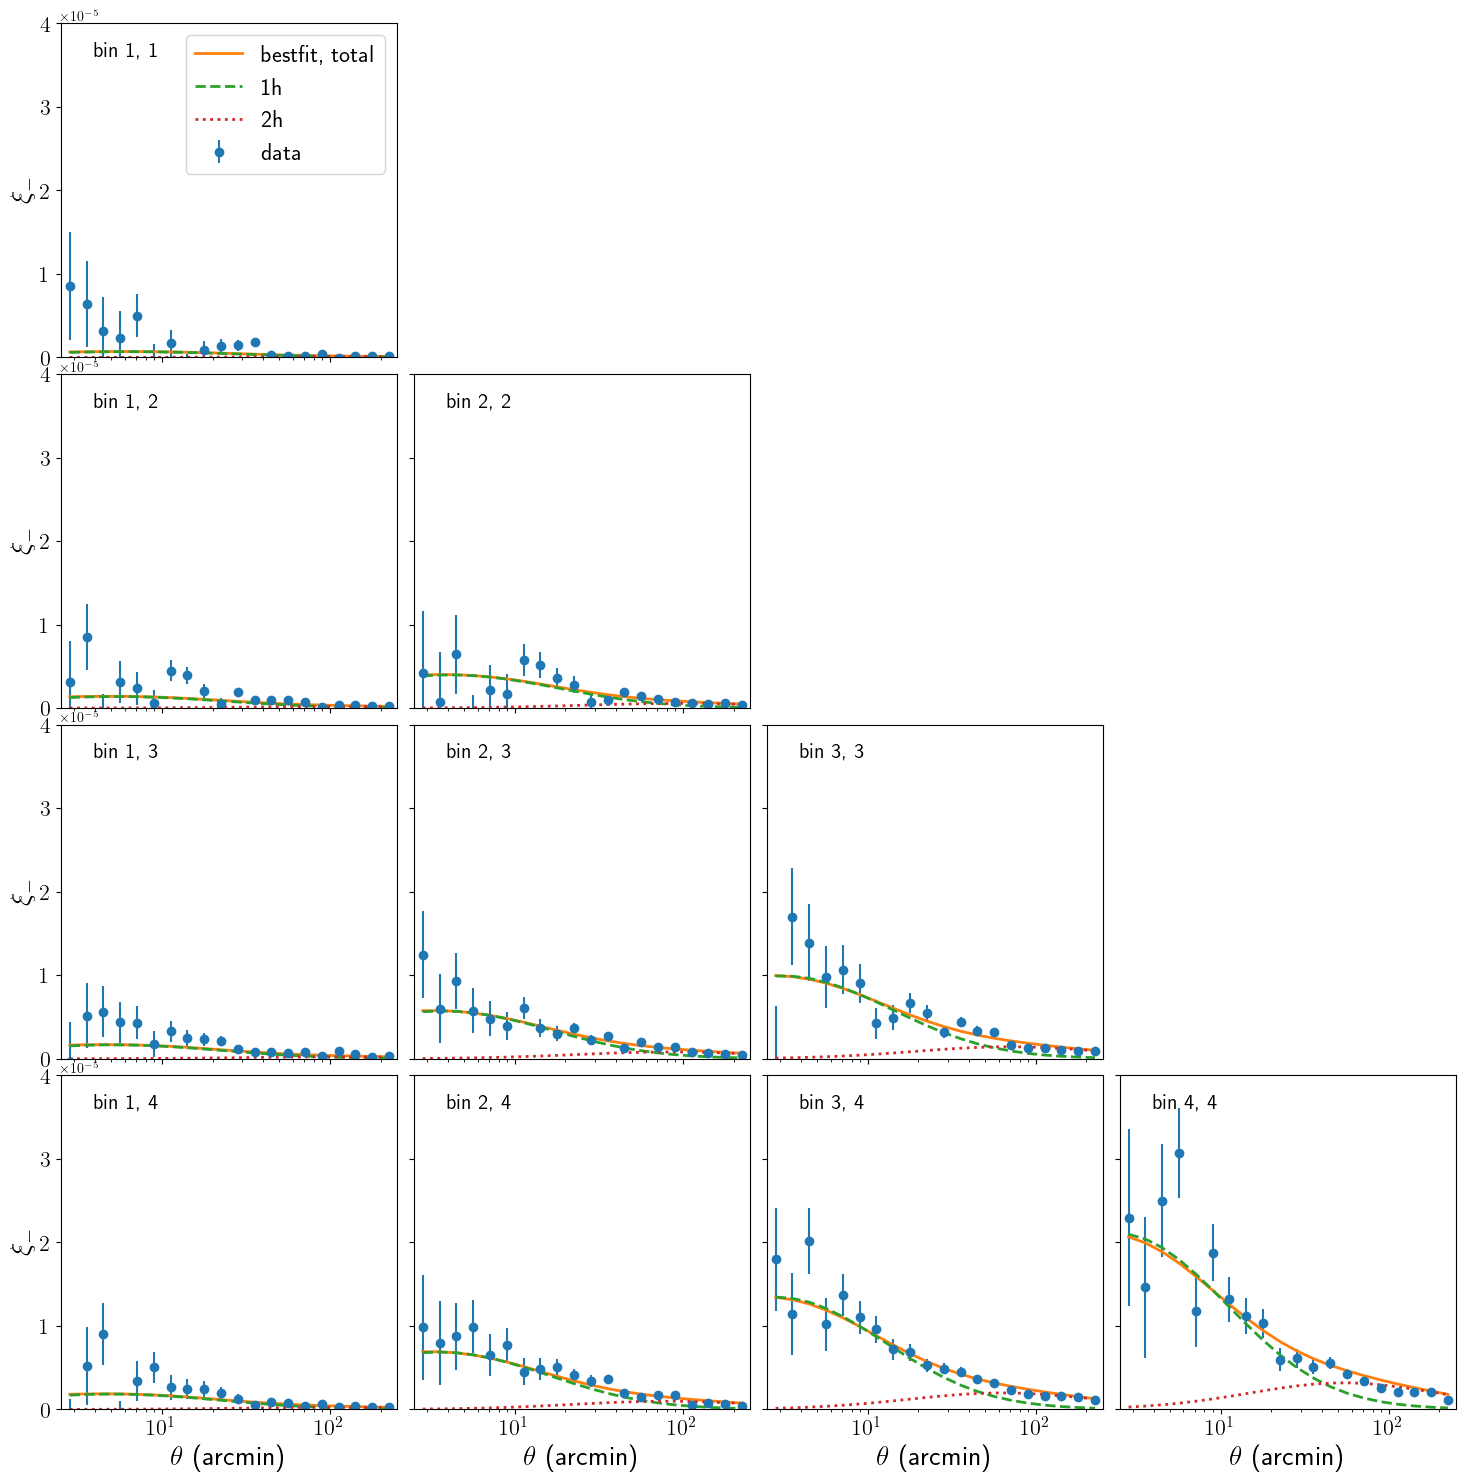

In [74]:
# make a four subplot figure:
theta_xip = theta_all[80:280]
theta_xim = theta_all[280:]
fig, axes = pl.subplots(4, 4, figsize=(18, 18), sharex=True, sharey=True)
# set spacing between suplots:
fig.subplots_adjust(hspace=0.05, wspace=0.05)
for ji1 in range(4):
    for ji2 in range(4):
        if ji1 <= ji2:
            ax = axes[ji2, ji1]
            indsel = np.where((bin1_xim_dv == ji1+1) & (bin2_xim_dv == ji2+1))[0]
            ax.errorbar(theta_xim[indsel], xim_dv[indsel], sig_xim_dv[indsel], label='data', ls='', marker='o')
            ax.plot(theta_xim[indsel], xim_all[indsel], label='bestfit, total', lw=2)
            ax.plot(theta_xim[indsel], xim_1h_ym[:,ji1, ji2], label='1h', lw=2, ls='--')
            ax.plot(theta_xim[indsel], xim_2h_ym[:,ji1, ji2], label='2h', lw=2, ls=':')
            # ax.plot(theta_xim[indsel], xim_hf_ym[:,ji1, ji2], label='Halofit', lw=2, ls='-.')
            # ax.set_title(f'gty bin {ji+1}')
            if ji1 == 0 and ji2 == 0:
                # ax.set_title('xim')
                ax.legend(fontsize=17)
            ax.set_xscale('log')
            # ax.set_yscale('log')
            ax.set_ylim(0, 4e-5)
            ax.set_xlim(2.5, 250)
            ax.text(0.1, 0.9, f'bin {ji1+1}, {ji2+1}', transform=ax.transAxes, fontsize=15)
            if ji2 == 3:
                ax.set_xlabel(r'$\theta$ (arcmin)', fontsize=20)
            if ji1 == 0:
                ax.set_ylabel(r'$\xi_{-}$', fontsize=20)
            ax.tick_params(axis='both', which='major', labelsize=16)
            ax.tick_params(axis='both', which='minor', labelsize=16)

            # if ji < 2:
                # ax.axvspan(0, 10, color='gray', alpha=0.2)
        else:
            # delete the subplot:
            fig.delaxes(axes[ji2, ji1])
    # ax.set_xlim(0, 20)
# pl.yscale('log')
# fig.savefig('/mnt/home/spandey/ceph/GODMAX/results/ACTxDES/xim_dv.png', bbox_inches='tight', dpi=300)
# sdir = '/projects/bdne/spandey3/new_godmax/GODMAX/results/DESxACT/plots/'
# fig.savefig(sdir + 'xim_dv_v10.pdf', bbox_inches='tight', dpi=300)
# fig.savefig(sdir + 'xim_dv_v12.pdf', bbox_inches='tight', dpi=300)
pl.show()






In [79]:
# params, w_init
get_value(lower_bounds)




[1.89256285 2.48904969 2.67687764 3.18883237]
[0.00092517 0.00042732 0.00039669 0.00023483]


Array(2.00012444, dtype=float64)

In [75]:
nbar_comoving_target


Array([0.00102137, 0.00052675, 0.00052116, 0.00028039], dtype=float64)

In [76]:
gal_bias_target


Array([1.4, 1.5, 1.9, 2.2], dtype=float64)

In [77]:
lower_bounds


Array([11.  , -1.  ,  0.05, -1.  ,  0.1 , -5.  ,  0.1 ,  0.5 ], dtype=float64)